Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 784)                 │         101,136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0696 - val_loss: 0.0498
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0410 - val_loss: 0.0355
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0335 - val_loss: 0.0309
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0295 - val_loss: 0.0277
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0272 - val_loss: 0.0262
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0258 - val_loss: 0.0250
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0248 - val_loss: 0.0240
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0239 - val_loss: 0.0232
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0231 - val_loss: 0.0225
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0225 - val_loss: 0.0219
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0218 - val_loss: 0.0213
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━

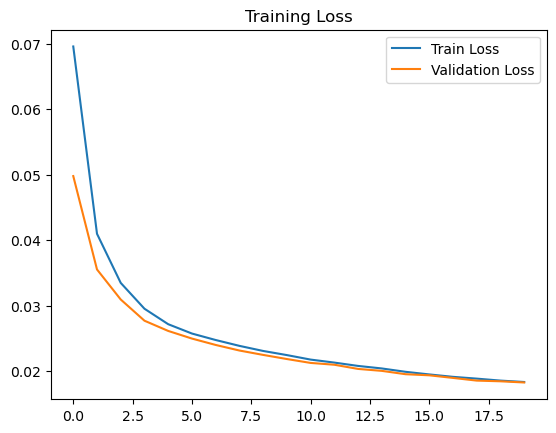

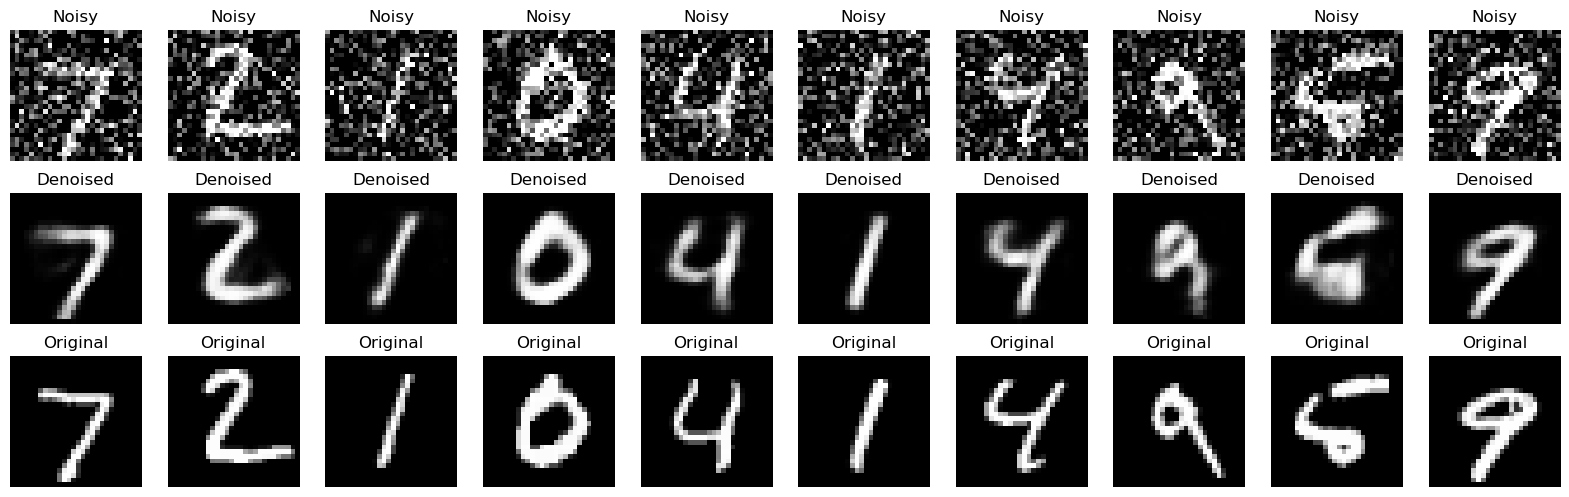

In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# ==============================
# 2. Load Dataset
# ==============================
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize (0-255 → 0-1)
x_train = x_train.astype("float32") / 255.
x_test  = x_test.astype("float32") / 255.

# Flatten images (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test  = x_test.reshape((len(x_test), 784))

# ==============================
# 3. Add Noise to Images
# ==============================
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.normal(size=x_test.shape)

# Clip values to keep pixels in range [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy  = np.clip(x_test_noisy, 0., 1.)

# ==============================
# 4. Build Autoencoder Model
# ==============================
input_img = Input(shape=(784,))

# ----- Encoder -----
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
latent  = Dense(32, activation='relu')(encoded)

# ----- Decoder -----
decoded = Dense(64, activation='relu')(latent)
decoded = Dense(128, activation='relu')(decoded)
output  = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_img, output)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

# ==============================
# 5. Train Model (Noisy → Clean)
# ==============================
history = autoencoder.fit(
    x_train_noisy, x_train,      # input=noisy, output=clean
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# ==============================
# 6. Reconstruct Images
# ==============================
decoded_imgs = autoencoder.predict(x_test_noisy)

# ==============================
# 7. Plot Loss
# ==============================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training Loss")
plt.show()

# ==============================
# 8. Show Noisy vs Denoised vs Original
# ==============================
n = 10
plt.figure(figsize=(20,6))

for i in range(n):
    # Noisy image
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised output
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    # Original image
    ax = plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

plt.show()